In [3]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, mean_squared_error

In [13]:
# Load all KCs from the final report (flagged and unflagged)
report = pd.read_excel('../notes/kc_report_final.xlsx')

report['skill_name'] = (
    report['Learning Objective (KC)']
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

print(f'{len(report)} KCs in report ({(report["Flagged"] == "No").sum()} unflagged, {(report["Flagged"] == "Yes").sum()} flagged)')
print(report[['Learning Objective (KC)', 'skill_name', 'Flagged', 'Flag Reasons']].to_string(index=False))

125 KCs in report (40 unflagged, 85 flagged)
                                                     Learning Objective (KC)                                                                   skill_name Flagged                       Flag Reasons
                                                                    accuracy                                                                     accuracy     Yes                          high_slip
                                                  add and subtract fractions                                                   add_and_subtract_fractions      No                                NaN
                                                                add integers                                                                 add_integers     Yes                         high_guess
                                      adding and subtracting complex numbers                                       adding_and_subtracting_complex_numbers      No      

In [14]:
# Load hint-adjusted fitted params
params_raw = pd.read_csv('data/fitted_params_hint_adjusted.csv')
params = params_raw.pivot_table(index='skill', columns='param', values='value')

covered = [s for s in report['skill_name'] if s in params.index]
missing = [s for s in report['skill_name'] if s not in params.index]

print(f'Params found: {len(covered)} / {len(report)}')
if missing:
    print(f'Missing from fitted params: {missing}')

Params found: 125 / 125


In [15]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from fit_bkt import hint_adjust_correct

df_raw = pd.read_csv('data/submissions.csv', low_memory=False)
df = hint_adjust_correct(df_raw)

df = df[df['knowledgeComponents'].notna()]
df['knowledgeComponents'] = df['knowledgeComponents'].apply(ast.literal_eval)
df = df.explode('knowledgeComponents')
df = df.rename(columns={
    'oats_user_id': 'user_id',
    'knowledgeComponents': 'skill_name',
    'time_stamp': 'order_id',
    'isCorrect': 'correct',
})
df['correct'] = df['correct'].astype(int)
df = df[['user_id', 'skill_name', 'order_id', 'correct']].dropna()
df = df.sort_values(['skill_name', 'user_id', 'order_id'])

print(f'{len(df):,} answerStep rows after hint adjustment')

  30,747 answers marked incorrect due to prior hint use
189,966 answerStep rows after hint adjustment


In [16]:
def bkt_forward(sequence, prior, learn, slip, guess, forget=0.0):
    """
    BKT forward pass. Returns predicted P(correct) at each step
    BEFORE observing that step's outcome.
    """
    p_know = prior
    predictions = []

    for obs in sequence:
        p_correct = p_know * (1 - slip) + (1 - p_know) * guess
        predictions.append(p_correct)

        #Bayesian update
        if obs == 1:
            numerator = p_know * (1 - slip)
            denominator = numerator + (1 - p_know) * guess
        else:
            numerator = p_know * slip
            denominator = numerator + (1 - p_know) * (1 - guess)
        p_know_post = numerator / (denominator + 1e-10)

        #Transition
        p_know = p_know_post * (1 - forget) + (1 - p_know_post) * learn

    return predictions

In [17]:
# Leave-last-out evaluation across all KCs in the report
# Primary metric: RMSE  |  Secondary: AUC-ROC
# Baseline: student history average (fraction correct on all steps before last)

results = []

for skill_name in covered:
    p = params.loc[skill_name]
    prior  = p['prior']
    learn  = p['learns']
    slip   = p['slips']
    guess  = p['guesses']
    forget = p.get('forgets', 0.0)

    skill_df = df[df['skill_name'] == skill_name]
    sequences = skill_df.groupby('user_id')['correct'].apply(list)
    sequences = sequences[sequences.apply(len) >= 2]

    if len(sequences) == 0:
        results.append({'skill': skill_name, 'note': 'no sequences >= 2'})
        continue

    y_true, y_bkt, y_base = [], [], []

    for seq in sequences:
        preds = bkt_forward(seq, prior, learn, slip, guess, forget)
        history = seq[:-1]
        y_true.append(seq[-1])
        y_bkt.append(preds[-1])
        y_base.append(sum(history) / len(history))

    y_true_arr = np.array(y_true)
    y_bkt_arr  = np.array(y_bkt)
    y_base_arr = np.array(y_base)

    lengths = sequences.apply(len)
    rmse_bkt  = np.sqrt(mean_squared_error(y_true_arr, y_bkt_arr))
    rmse_base = np.sqrt(mean_squared_error(y_true_arr, y_base_arr))

    row = {
        'skill':         skill_name,
        'n_students':    len(sequences),
        'n_predictions': len(y_true),
        'pct_len2':      round((lengths == 2).mean() * 100, 1),
        'rmse_bkt':      round(rmse_bkt, 4),
        'rmse_baseline': round(rmse_base, 4),
        'delta_rmse':    round(rmse_base - rmse_bkt, 4),
        'note': '',
    }

    if len(set(y_true)) < 2:
        row['auc_bkt']      = float('nan')
        row['auc_baseline'] = float('nan')
        row['delta_auc']    = float('nan')
        row['note']         = 'all same label — AUC undefined'
    else:
        row['auc_bkt']      = round(roc_auc_score(y_true_arr, y_bkt_arr), 4)
        row['auc_baseline'] = round(roc_auc_score(y_true_arr, y_base_arr), 4)
        row['delta_auc']    = round(row['auc_bkt'] - row['auc_baseline'], 4)

    results.append(row)

eval_df = pd.DataFrame(results).set_index('skill')

# Join flagged status from report
flag_info = report.set_index('skill_name')[['Flagged', 'Flag Reasons']]
eval_df = eval_df.join(flag_info)

col_order = ['Flagged', 'Flag Reasons', 'n_students', 'n_predictions', 'pct_len2',
             'rmse_bkt', 'rmse_baseline', 'delta_rmse',
             'auc_bkt', 'auc_baseline', 'delta_auc', 'note']
eval_df = eval_df[col_order].sort_values('rmse_bkt')

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.max_rows', 100)
display(eval_df)

,Flagged,Flag Reasons,n_students,n_predictions,pct_len2,rmse_bkt,rmse_baseline,delta_rmse,auc_bkt,auc_baseline,delta_auc,note
skill,,,,,,,,,,,,
using_the_zero_exponent_rule_of_exponents,Yes,"low_transit, high_prior",27,27,3.70000,0.10530,0.20250,0.09730,1.00000,1.00000,0.00000,
multiply_and_divide_fractions,Yes,high_prior,24,24,12.50000,0.15930,0.31990,0.16060,1.00000,1.00000,0.00000,
sql,Yes,high_guess,34,34,2.90000,0.18410,0.22530,0.04130,1.00000,1.00000,0.00000,
simplify_fractions,Yes,high_guess,26,26,15.40000,0.18580,0.14710,-0.03870,1.00000,1.00000,0.00000,
finding_the_quotient_of_a_product,No,NaN,27,27,0.00000,0.18880,0.29140,0.10260,1.00000,0.98000,0.02000,
...,...,...,...,...,...,...,...,...,...,...,...,...
using_a_formula_to_solve_a_real_world_application,No,NaN,20,20,20.00000,0.51540,0.56750,0.05210,0.96880,0.89840,0.07040,
accuracy,Yes,high_slip,18,18,22.20000,0.52230,0.64440,0.12210,0.54550,0.51300,0.03250,
and_significant_figures,Yes,"high_slip, high_prior",18,18,22.20000,0.52270,0.64440,0.12160,0.54550,0.51300,0.03250,


In [9]:
valid = eval_df[eval_df['rmse_bkt'].notna()]

print(f'KCs evaluated: {len(valid)}')
print()
print('— RMSE (primary) —')
print(f'  BKT beats baseline: {(valid["delta_rmse"] > 0).sum()} / {len(valid)}')
print(f'  Median RMSE BKT:      {valid["rmse_bkt"].median():.4f}')
print(f'  Median RMSE baseline: {valid["rmse_baseline"].median():.4f}')
print(f'  Median ΔRMSE (baseline − BKT): {valid["delta_rmse"].median():.4f}')
print()
print('— AUC (secondary) —')
auc_valid = valid[valid['auc_bkt'].notna()]
print(f'  BKT beats baseline: {(auc_valid["delta_auc"] > 0).sum()} / {len(auc_valid)}')
print(f'  BKT AUC > 0.5:      {(auc_valid["auc_bkt"] > 0.5).sum()} / {len(auc_valid)}')
print(f'  Median AUC BKT:      {auc_valid["auc_bkt"].median():.4f}')
print(f'  Median AUC baseline: {auc_valid["auc_baseline"].median():.4f}')
print(f'  Median ΔAUC:         {auc_valid["delta_auc"].median():.4f}')
print()
print('Best KCs by RMSE (lowest = best):')
print(valid['rmse_bkt'].head(5).to_string())
print()
print('Worst KCs by RMSE:')
print(valid['rmse_bkt'].tail(5).to_string())

KCs evaluated: 40

— RMSE (primary) —
  BKT beats baseline: 35 / 40
  Median RMSE BKT:      0.3368
  Median RMSE baseline: 0.3993
  Median ΔRMSE (baseline − BKT): 0.0576

— AUC (secondary) —
  BKT beats baseline: 24 / 40
  BKT AUC > 0.5:      39 / 40
  Median AUC BKT:      0.8835
  Median AUC baseline: 0.8867
  Median ΔAUC:         0.0161

Best KCs by RMSE (lowest = best):
skill
finding_the_quotient_of_a_product               0.18880
evaluate_variable_expressions_with_integers     0.19210
using_the_product_exponent_rule_of_exponents    0.19560
using_the_quotient_exponent_rule_of_exponents   0.19970
finding_the_power_of_a_product                  0.21220

Worst KCs by RMSE:
skill
simplifying_powers_of_i                             0.48640
fitting_linear_models_to_data                       0.48950
multiply_and_divide_integers                        0.49630
finding_x_intercepts_and_y_intercepts               0.49640
using_a_formula_to_solve_a_real_world_application   0.51540


In [ ]:
# Decision rules (baseline = student history average — stronger than prior-only)
#
# Keep:       delta_rmse > 0  AND  auc_bkt > 0.70
# Inspect:    (delta_rmse > 0  AND  0.65 <= auc_bkt <= 0.70)
#             OR (delta_rmse >= -0.05  AND  auc_bkt > 0.70)
# Drop/Flag:  delta_rmse < -0.05  OR  auc_bkt < 0.65

def categorize(row):
    rmse_better   = row['delta_rmse'] > 0
    rmse_close    = row['delta_rmse'] >= -0.05
    auc_strong    = row['auc_bkt'] > 0.70
    auc_border    = 0.65 <= row['auc_bkt'] <= 0.70

    if rmse_better and auc_strong:
        return 'keep'
    elif (rmse_better and auc_border) or (rmse_close and auc_strong):
        return 'inspect'
    else:
        return 'drop/flag'

valid['verdict'] = valid.apply(categorize, axis=1)

counts = valid['verdict'].value_counts()
print('Verdict counts:')
print(counts.to_string())
print()

for verdict in ['keep', 'inspect', 'drop/flag']:
    subset = valid[valid['verdict'] == verdict].sort_values('rmse_bkt')
    print(f'── {verdict.upper()} ({len(subset)}) ──────────────────────────────')
    if len(subset):
        print(subset[['rmse_bkt', 'delta_rmse', 'auc_bkt', 'delta_auc']].to_string())
    print()

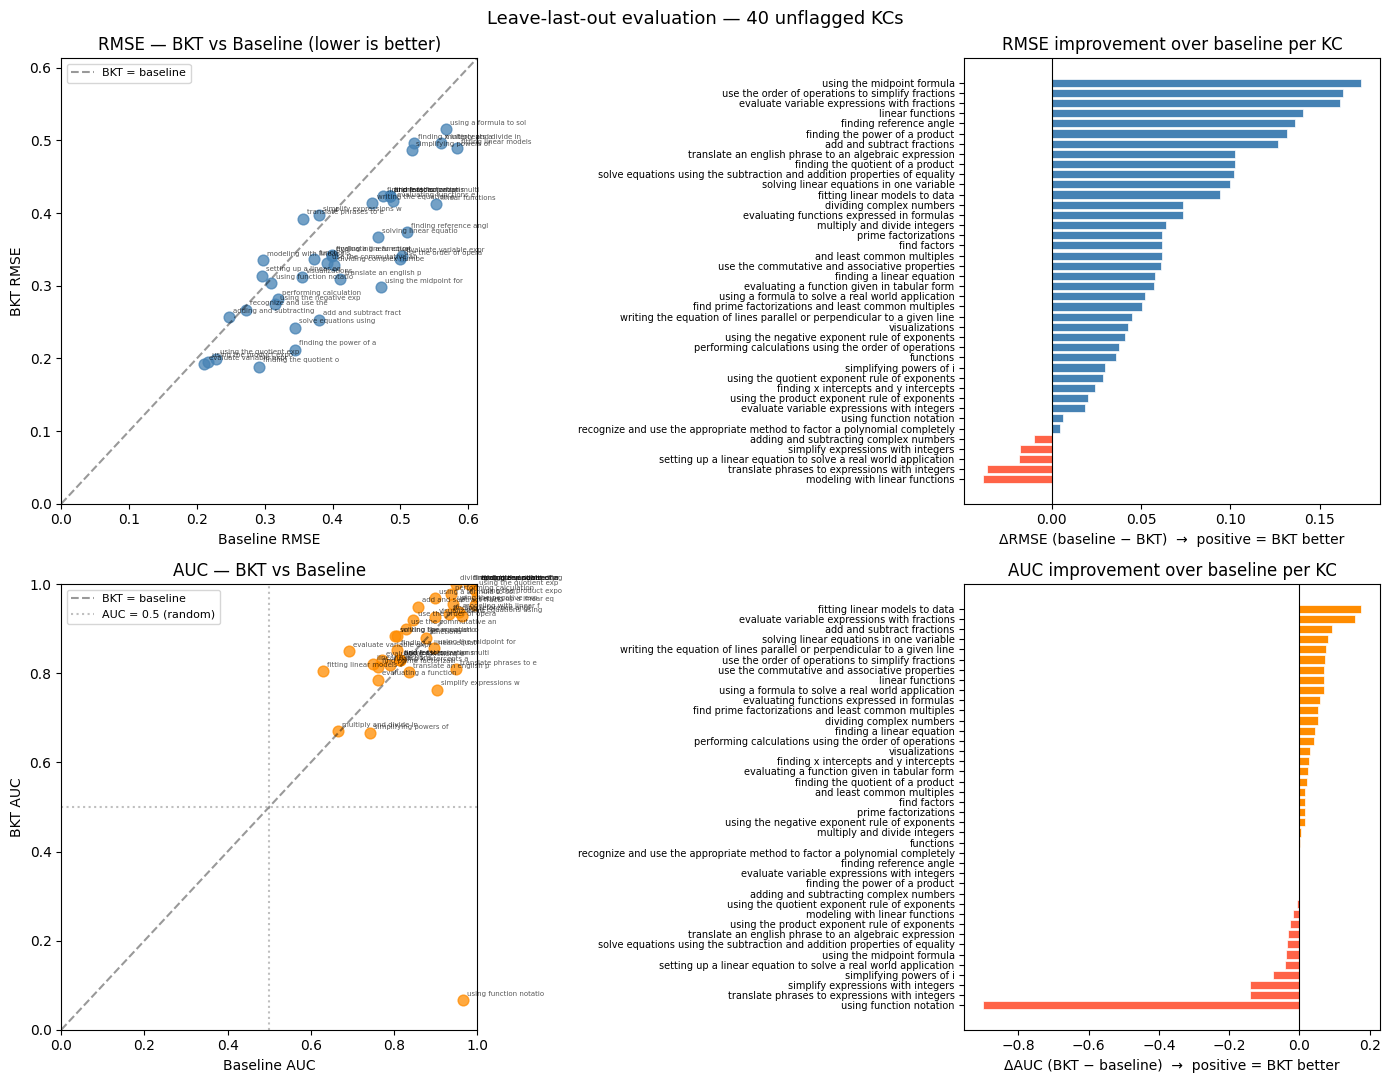

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ── RMSE scatter ──────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(valid['rmse_baseline'], valid['rmse_bkt'], alpha=0.75, s=60, color='steelblue')
lims = [0, max(valid['rmse_bkt'].max(), valid['rmse_baseline'].max()) * 1.05]
ax.plot(lims, lims, 'k--', alpha=0.4, label='BKT = baseline')
ax.set_xlabel('Baseline RMSE')
ax.set_ylabel('BKT RMSE')
ax.set_title('RMSE — BKT vs Baseline (lower is better)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(fontsize=8)
for s, row in valid.iterrows():
    ax.annotate(s.replace('_', ' ')[:22], (row['rmse_baseline'], row['rmse_bkt']),
                fontsize=5, alpha=0.65, xytext=(3, 3), textcoords='offset points')

# ── RMSE delta bar ────────────────────────────────────────────────────────────
ax = axes[0, 1]
sorted_rmse = valid.sort_values('delta_rmse')
colors = ['steelblue' if d >= 0 else 'tomato' for d in sorted_rmse['delta_rmse']]
ax.barh(range(len(sorted_rmse)), sorted_rmse['delta_rmse'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(sorted_rmse)))
ax.set_yticklabels([s.replace('_', ' ') for s in sorted_rmse.index], fontsize=7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ΔRMSE (baseline − BKT)  →  positive = BKT better')
ax.set_title('RMSE improvement over baseline per KC')

# ── AUC scatter ───────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(auc_valid['auc_baseline'], auc_valid['auc_bkt'], alpha=0.75, s=60, color='darkorange')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='BKT = baseline')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='AUC = 0.5 (random)')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Baseline AUC')
ax.set_ylabel('BKT AUC')
ax.set_title('AUC — BKT vs Baseline')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=8)
for s, row in auc_valid.iterrows():
    ax.annotate(s.replace('_', ' ')[:22], (row['auc_baseline'], row['auc_bkt']),
                fontsize=5, alpha=0.65, xytext=(3, 3), textcoords='offset points')

# ── AUC delta bar ─────────────────────────────────────────────────────────────
ax = axes[1, 1]
sorted_auc = auc_valid.sort_values('delta_auc')
colors = ['darkorange' if d >= 0 else 'tomato' for d in sorted_auc['delta_auc']]
ax.barh(range(len(sorted_auc)), sorted_auc['delta_auc'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(sorted_auc)))
ax.set_yticklabels([s.replace('_', ' ') for s in sorted_auc.index], fontsize=7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ΔAUC (BKT − baseline)  →  positive = BKT better')
ax.set_title('AUC improvement over baseline per KC')

plt.suptitle('Leave-last-out evaluation — 40 unflagged KCs', fontsize=13)
plt.tight_layout()
plt.show()

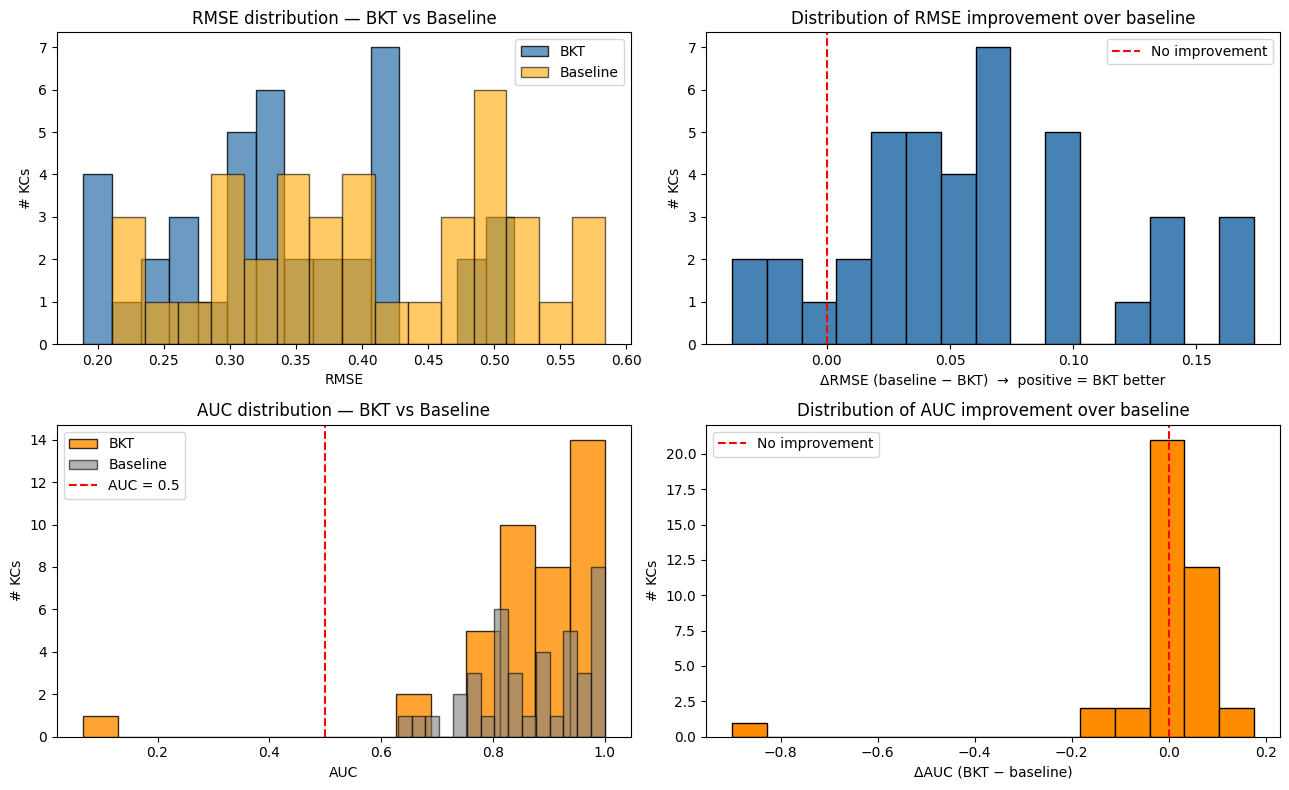

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# RMSE distributions
ax = axes[0, 0]
ax.hist(valid['rmse_bkt'], bins=15, edgecolor='black', color='steelblue', alpha=0.8, label='BKT')
ax.hist(valid['rmse_baseline'], bins=15, edgecolor='black', color='orange', alpha=0.6, label='Baseline')
ax.set_xlabel('RMSE')
ax.set_ylabel('# KCs')
ax.set_title('RMSE distribution — BKT vs Baseline')
ax.legend()

ax = axes[0, 1]
ax.hist(valid['delta_rmse'], bins=15, edgecolor='black', color='steelblue')
ax.axvline(0, color='red', linestyle='--', label='No improvement')
ax.set_xlabel('ΔRMSE (baseline − BKT)  →  positive = BKT better')
ax.set_ylabel('# KCs')
ax.set_title('Distribution of RMSE improvement over baseline')
ax.legend()

# AUC distributions
ax = axes[1, 0]
ax.hist(auc_valid['auc_bkt'], bins=15, edgecolor='black', color='darkorange', alpha=0.8, label='BKT')
ax.hist(auc_valid['auc_baseline'], bins=15, edgecolor='black', color='gray', alpha=0.6, label='Baseline')
ax.axvline(0.5, color='red', linestyle='--', label='AUC = 0.5')
ax.set_xlabel('AUC')
ax.set_ylabel('# KCs')
ax.set_title('AUC distribution — BKT vs Baseline')
ax.legend()

ax = axes[1, 1]
ax.hist(auc_valid['delta_auc'], bins=15, edgecolor='black', color='darkorange')
ax.axvline(0, color='red', linestyle='--', label='No improvement')
ax.set_xlabel('ΔAUC (BKT − baseline)')
ax.set_ylabel('# KCs')
ax.set_title('Distribution of AUC improvement over baseline')
ax.legend()

plt.tight_layout()
plt.show()

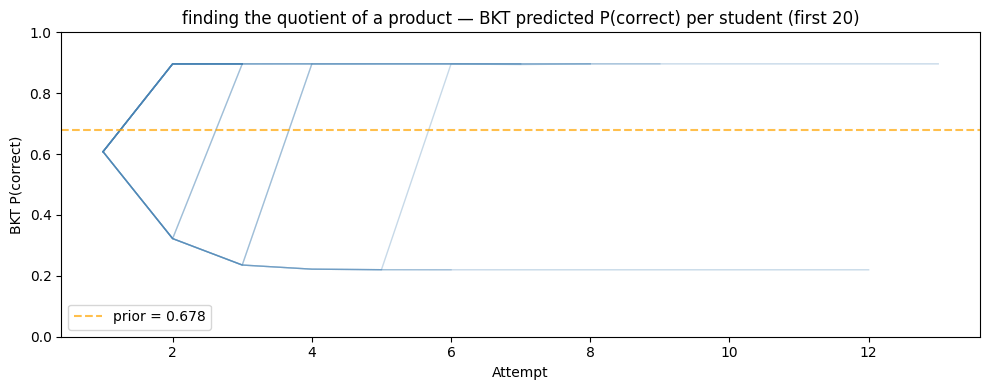

KC: finding_the_quotient_of_a_product
  RMSE BKT:      0.1888
  RMSE baseline: 0.2914
  ΔRMSE:         0.1026
  AUC BKT:       1.0
  AUC baseline:  0.98
  ΔAUC:          0.02
  Params — prior=0.678, learn=0.220, slip=0.104, guess=0.000


In [12]:
# Per-KC detail: predicted probability traces for a single KC
# Change KC_NAME to inspect any KC from the evaluated set
KC_NAME = valid.index[0]  # lowest RMSE KC by default

p = params.loc[KC_NAME]
prior, learn, slip, guess = p['prior'], p['learns'], p['slips'], p['guesses']
forget = p.get('forgets', 0.0)

skill_df = df[df['skill_name'] == KC_NAME]
sequences = skill_df.groupby('user_id')['correct'].apply(list)
sequences = sequences[sequences.apply(len) >= 2]

fig, ax = plt.subplots(figsize=(10, 4))
for seq in list(sequences)[:20]:
    preds = bkt_forward(seq, prior, learn, slip, guess, forget)
    ax.plot(range(1, len(preds) + 1), preds, alpha=0.3, color='steelblue', linewidth=1)

ax.set_xlabel('Attempt')
ax.set_ylabel('BKT P(correct)')
ax.set_ylim(0, 1)
ax.set_title(f'{KC_NAME.replace("_", " ")} — BKT predicted P(correct) per student (first 20)')
ax.axhline(p['prior'], color='orange', linestyle='--', alpha=0.7, label=f'prior = {p["prior"]:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

kc_eval = eval_df.loc[KC_NAME]
print(f'KC: {KC_NAME}')
print(f'  RMSE BKT:      {kc_eval["rmse_bkt"]}')
print(f'  RMSE baseline: {kc_eval["rmse_baseline"]}')
print(f'  ΔRMSE:         {kc_eval["delta_rmse"]}')
print(f'  AUC BKT:       {kc_eval["auc_bkt"]}')
print(f'  AUC baseline:  {kc_eval["auc_baseline"]}')
print(f'  ΔAUC:          {kc_eval["delta_auc"]}')
print(f'  Params — prior={prior:.3f}, learn={learn:.3f}, slip={slip:.3f}, guess={guess:.3f}')

In [18]:
out = eval_df.sort_index().reset_index().rename(columns={'skill': 'Learning Objective (KC)'})
out.to_excel('../notes/eval_results.xlsx', index=False)
print(f'Saved {len(out)} rows to notes/eval_results.xlsx')

Saved 125 rows to notes/eval_results.xlsx
